In [321]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#KMeans algorithm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Hierarchical algorithm

from scipy.cluster.hierarchy import cut_tree
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

In [322]:
df = pd.read_csv('/content/Online Retail.csv')
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [323]:
#pip install ucimlrepo


In [324]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [325]:
df.isnull().sum() # find the sum of null present in the dataframe

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [326]:
round((df.isnull().sum()/len(df)),2) # null values in dataframe as percentage

,0
InvoiceNo,0.00
StockCode,0.00
Description,0.00
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
CustomerID,0.25
Country,0.00


In [327]:
df = df.dropna()
df.shape

(406829, 8)

In [328]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [329]:
# monetary value
df['amount'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [330]:
grouped_df = df.groupby('CustomerID')['amount'].sum()
grouped_df.reset_index()
grouped_df.head()

,amount
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40


In [331]:
#Frequency
frequency = df.groupby('CustomerID')['InvoiceNo'].count()

In [332]:
frequency.reset_index()
frequency.head()

,InvoiceNo
CustomerID,
12346.0,2
12347.0,182
12348.0,31
12349.0,73
12350.0,17


In [333]:
grouped_df =pd.merge(grouped_df,frequency,on='CustomerID',how='inner')
grouped_df.head()

,amount,InvoiceNo
CustomerID,,
12346.0,0.00,2
12347.0,4310.00,182
12348.0,1797.24,31
12349.0,1757.55,73
12350.0,334.40,17


In [334]:
print(type(grouped_df))

<class 'pandas.core.frame.DataFrame'>


In [335]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format='%d-%m-%Y %H:%M')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [336]:
max_date = max(df['InvoiceDate'])
max_date

Timestamp('2011-12-09 12:50:00')

In [337]:
df['diff'] = max_date - df['InvoiceDate']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount,diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [338]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [339]:
# recency
last_purchase = df.groupby('CustomerID')['diff'].min()
last_purchase.reset_index()
last_purchase.head()

,diff
CustomerID,
12346.0,325 days 02:33:00
12347.0,1 days 20:58:00
12348.0,74 days 23:37:00
12349.0,18 days 02:59:00
12350.0,309 days 20:49:00


In [340]:
grouped_df = pd.merge(grouped_df,last_purchase,on='CustomerID',how='inner')
grouped_df.head()

,amount,InvoiceNo,diff
CustomerID,,,
12346.0,0.00,2,325 days 02:33:00
12347.0,4310.00,182,1 days 20:58:00
12348.0,1797.24,31,74 days 23:37:00
12349.0,1757.55,73,18 days 02:59:00
12350.0,334.40,17,309 days 20:49:00


In [341]:
print(type(grouped_df))

<class 'pandas.core.frame.DataFrame'>


In [342]:
grouped_df.columns = ['amount','frequency','recency']

In [343]:
print(type(grouped_df))

<class 'pandas.core.frame.DataFrame'>


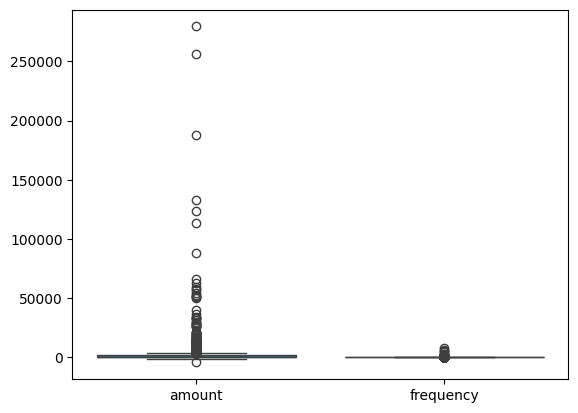

In [344]:
#plot

sns.boxplot(grouped_df)
plt.show()

In [345]:
grouped_df.head(2)

,amount,frequency,recency
CustomerID,,,
12346.0,0.0,2,325 days 02:33:00
12347.0,4310.0,182,1 days 20:58:00


In [346]:
print(type(grouped_df))
print(grouped_df.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['amount', 'frequency', 'recency'], dtype='object')


In [347]:
grouped_df['recency'] = grouped_df['recency'].dt.days

In [348]:
# Outliers Treatment #RFM
Q1 = grouped_df.amount.quantile(0.05)
Q3 = grouped_df.amount.quantile(0.95)
IQR = Q3-Q1
grouped_df = grouped_df[(grouped_df.amount >= Q1 - 1.5*IQR)&(grouped_df.amount <= Q3 + 1.5*IQR)]
grouped_df.head(2)

,amount,frequency,recency
CustomerID,,,
12346.0,0.0,2,325
12347.0,4310.0,182,1


In [349]:

# Outliers Treatment #RFM
Q1 = grouped_df.frequency.quantile(0.05)
Q3 = grouped_df.frequency.quantile(0.95)
IQR = Q3-Q1
grouped_df = grouped_df[(grouped_df.frequency >= Q1 - 1.5*IQR)&(grouped_df.frequency <= Q3 + 1.5*IQR)]
grouped_df.head(2)

,amount,frequency,recency
CustomerID,,,
12346.0,0.0,2,325
12347.0,4310.0,182,1


In [350]:
# Outliers Treatment #RFM
Q1 = grouped_df.recency.quantile(0.05)
Q3 = grouped_df.recency.quantile(0.95)
IQR = Q3-Q1
grouped_df = grouped_df[(grouped_df.recency >= Q1 - 1.5*IQR)&(grouped_df.recency <= Q3 + 1.5*IQR)]
grouped_df.head(2)

,amount,frequency,recency
CustomerID,,,
12346.0,0.0,2,325
12347.0,4310.0,182,1


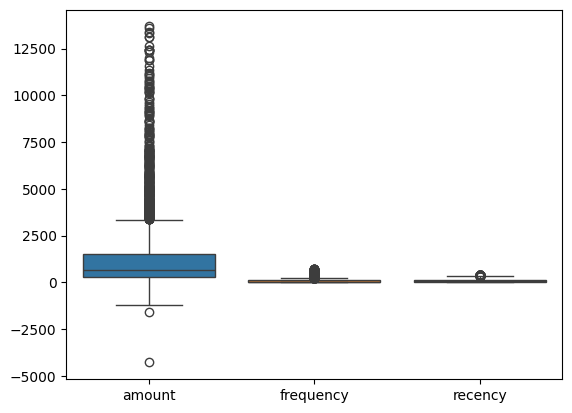

In [351]:
sns.boxplot(grouped_df)
plt.show()